In [2]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
CANDIDATE_PATHS = [
    "/kaggle/input/datasets/yoonthiriaung/working-data-latest/working_dataset_10_9_2026_latest.csv"
]

df = None
for p in CANDIDATE_PATHS:
    try:
        df = pd.read_csv(p)
        DATA_PATH = p
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError(
        "Could not find the working dataset. Set DATA_PATH manually to the "
        "working_dataset_*.csv produced in cleaned.ipynb (the version with balanced_score already computed)."
    )

print(f"Loaded: {DATA_PATH}")
print("Shape:", df.shape)

Loaded: /kaggle/input/datasets/yoonthiriaung/working-data-latest/working_dataset_10_9_2026_latest.csv
Shape: (8227, 36)


In [3]:
# ------------------------------------------------------------
# Re-parse the multi-label columns, which round-trip through CSV as strings
# (e.g. "['Action', 'Adventure']") rather than real Python lists.
# ------------------------------------------------------------
def parse_list_col(x):
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except (ValueError, SyntaxError):
        return []

LIST_COLS = ['genres', 'studios', 'themes', 'producers', 'demographics']
for col in LIST_COLS:
    if col in df.columns:
        df[col] = df[col].apply(parse_list_col)

assert 'balanced_score' in df.columns, "balanced_score column missing — load the post-feature-engineering working dataset, not the raw cleaned dataset."

d = df.copy()
print(d[LIST_COLS].head(3))
print("\nRows with balanced_score present:", d['balanced_score'].notna().sum())

                                genres       studios                      themes                                          producers demographics
0            [Action, Drama, Suspense]  [Wit Studio]  [Gore, Military, Survival]  [Production I.G, Dentsu, Mainichi Broadcasting...    [Shounen]
1             [Supernatural, Suspense]    [Madhouse]             [Psychological]  [VAP, Nippon Television Network, Shueisha, D.N...    [Shounen]
2  [Action, Adventure, Drama, Fantasy]       [Bones]                  [Military]  [Aniplex, Square Enix, Mainichi Broadcasting S...    [Shounen]

Rows with balanced_score present: 8227


In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8227 entries, 0 to 8226
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mal_id                8227 non-null   int64  
 1   title                 8227 non-null   object 
 2   title_english         5979 non-null   object 
 3   title_japanese        8209 non-null   object 
 4   title_synonym         5026 non-null   object 
 5   type                  8227 non-null   object 
 6   source                8227 non-null   object 
 7   status                8227 non-null   object 
 8   rating                8227 non-null   object 
 9   score                 8227 non-null   float64
 10  scored_by             8227 non-null   float64
 11  rank                  8227 non-null   float64
 12  popularity            8227 non-null   int64  
 13  members               8227 non-null   int64  
 14  favorites             8227 non-null   int64  
 15  season               

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD

dm = d[(d['year'] >= 2010) & (d['status'] == 'Finished Airing')].copy().reset_index(drop=True)
print('Modeling rows:', dm.shape)

def time_split(data, train_end=2022, val_end=2023):
    train = data[data['year'] <= train_end].copy()
    val = data[(data['year'] > train_end) & (data['year'] <= val_end)].copy()
    test = data[data['year'] > val_end].copy()
    return train, val, test

train_df, val_df, test_df = time_split(dm)
print('Train:', train_df.shape, ' Val:', val_df.shape, ' Test:', test_df.shape)


Modeling rows: (6659, 36)
Train: (5165, 36)  Val: (480, 36)  Test: (1014, 36)


In [6]:

# Success threshold defined from the TRAINING distribution only (top quartile of balanced_score)
success_threshold = train_df['balanced_score'].quantile(0.75)
for split in (train_df, val_df, test_df):
    split['is_success_b'] = (split['balanced_score'] >= success_threshold).astype(int)
print('Success threshold (train 75th pct of balanced_score):', round(success_threshold, 4))
print('Success rate — train: {:.1%}  val: {:.1%}  test: {:.1%}'.format(
    train_df['is_success_b'].mean(), val_df['is_success_b'].mean(), test_df['is_success_b'].mean()))


Success threshold (train 75th pct of balanced_score): 0.6946
Success rate — train: 25.0%  val: 24.6%  test: 23.4%


In [7]:
for name, split in [
    ('Train', train_df),
    ('Validation', val_df),
    ('Test', test_df)
]:
    print(f'\n{name}')
    print(split['is_success_b'].value_counts().sort_index())
    print(split['is_success_b'].value_counts(normalize=True).sort_index())


Train
is_success_b
0    3873
1    1292
Name: count, dtype: int64
is_success_b
0    0.749855
1    0.250145
Name: proportion, dtype: float64

Validation
is_success_b
0    362
1    118
Name: count, dtype: int64
is_success_b
0    0.754167
1    0.245833
Name: proportion, dtype: float64

Test
is_success_b
0    777
1    237
Name: count, dtype: int64
is_success_b
0    0.766272
1    0.233728
Name: proportion, dtype: float64


In [8]:
class FeatureBuilder:
    """Builds a pre-release-knowable feature matrix. Every historical-average statistic
    is fit on the TRAIN split only, then applied unchanged to val/test."""

    def __init__(self, top_genre_n=25, top_theme_n=20, top_studio_n=30, svd_dim=20):
        self.top_genre_n, self.top_theme_n, self.top_studio_n, self.svd_dim = top_genre_n, top_theme_n, top_studio_n, svd_dim

    def fit(self, train):
        self.genre_vocab = train['genres'].explode().value_counts().head(self.top_genre_n).index.tolist()
        self.theme_vocab = train['themes'].explode().value_counts().head(self.top_theme_n).index.tolist()
        studio_vc = train['studios'].explode().value_counts()
        self.studio_vocab = studio_vc[studio_vc >= 10].head(self.top_studio_n).index.tolist()
        self.demo_vocab = train['demographics'].explode().dropna().unique().tolist()
        self.source_vocab = train['source'].dropna().unique().tolist()
        self.type_vocab = train['type'].dropna().unique().tolist()
        self.rating_vocab = train['rating'].dropna().unique().tolist()
        self.season_vocab = train['season'].dropna().unique().tolist()

        # Historical avg balanced_score -- TRAIN ONLY, used as a track-record feature (not leakage:
        # it summarizes OTHER, earlier titles, never the current row's own outcome)
        self.studio_perf = train.explode('studios').groupby('studios')['balanced_score'].mean()
        self.global_bscore_mean = train['balanced_score'].mean()
        self.source_perf = train.groupby('source')['balanced_score'].mean()

        self.episodes_median = train['episodes'].median()
        self.duration_median = train['duration_minutes'].median()

        meta_stop = {
            'season', 'seasons', 'episode', 'episodes', 'ova', 'ona', 'special', 'specials', 'movie', 'movies',
            'film', 'films', 'short', 'shorts', 'recap', 'sequel', 'tv', 'series', 'anime', 'adaptation', 'adapted',
            'bundled', 'volume', 'volumes', 'manga', 'light', 'novel', 'novels', 'game', 'games', 'video', 'anniversary',
            'collaboration', 'mini', 'characters', 'character', 'based', 'second', 'third', 'fourth', 'fifth', 'sixth',
            'part', 'story', 'stories', 'animated', 'animation', 'source', 'studio', 'aired',
        }
        stopwords = list(ENGLISH_STOP_WORDS.union(meta_stop))
        self.tfidf = TfidfVectorizer(max_features=3000, stop_words=stopwords, ngram_range=(1, 2), min_df=3, max_df=0.4)
        X_text = self.tfidf.fit_transform(train['synopsis_clean'].fillna(''))
        self.svd = TruncatedSVD(n_components=self.svd_dim, random_state=42)
        self.svd.fit(X_text)
        return self

    def transform(self, data):
        out = pd.DataFrame(index=data.index)
        for g in self.genre_vocab: out[f'genre_{g}'] = data['genres'].apply(lambda lst: int(g in lst))
        for t in self.theme_vocab: out[f'theme_{t}'] = data['themes'].apply(lambda lst: int(t in lst))
        for dmg in self.demo_vocab: out[f'demo_{dmg}'] = data['demographics'].apply(lambda lst: int(dmg in lst))
        for s in self.source_vocab: out[f'source_{s}'] = (data['source'] == s).astype(int)
        for ty in self.type_vocab: out[f'type_{ty}'] = (data['type'] == ty).astype(int)
        for r in self.rating_vocab: out[f'rating_{r}'] = (data['rating'] == r).astype(int)
        for se in self.season_vocab: out[f'season_{se}'] = (data['season'] == se).astype(int)

        def studio_hist(lst):
            vals = [self.studio_perf.loc[s] for s in lst if s in self.studio_perf.index]
            return np.mean(vals) if vals else self.global_bscore_mean
        out['studio_hist_balanced'] = data['studios'].apply(studio_hist)
        out['studio_is_known'] = data['studios'].apply(lambda lst: int(any(s in self.studio_vocab for s in lst)))
        out['num_studios'] = data['studios'].apply(len)
        out['num_producers'] = data['producers'].apply(len)
        out['source_hist_balanced'] = data['source'].map(self.source_perf).fillna(self.global_bscore_mean)
        
        out['episodes'] = data['episodes'].fillna(self.episodes_median)

        out['duration_minutes'] = data['duration_minutes'].fillna(self.duration_median)
        out['year'] = data['year']
        out['num_genres'] = data['genres'].apply(len)
        out['num_themes'] = data['themes'].apply(len)

        X_text = self.tfidf.transform(data['synopsis_clean'].fillna(''))
        X_svd = self.svd.transform(X_text)
        for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
        return out


fb = FeatureBuilder().fit(train_df)
X_train, X_val, X_test = fb.transform(train_df), fb.transform(val_df), fb.transform(test_df)
print('Feature matrix shape:', X_train.shape)
print([c for c in X_train.columns if 'score' in c or 'member' in c or 'popular' in c or 'favorite' in c] or 'No leaked columns present ✔')


Feature matrix shape: (5165, 108)
No leaked columns present ✔


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ============================================================
#  TARGET
# ============================================================

y_train_cls = train_df['is_success_b']
y_val_cls   = val_df['is_success_b']
y_test_cls  = test_df['is_success_b']


# ============================================================
# SCALE FEATURES FOR LOGISTIC REGRESSION
# ============================================================

scaler = StandardScaler()

Xtr_s = scaler.fit_transform(X_train)
Xv_s  = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)


scale_pos_weight: 2.9977
After SMOTE: (7746, 108) balance:
 is_success_b
1    0.5
0    0.5
Name: proportion, dtype: float64

=== STRATEGY A: class-weighting (TEST) ===
               model  accuracy  precision  recall     f1  roc_auc
            XGBoost    0.7091     0.4350  0.8186 0.5681   0.8453
      Random Forest    0.7101     0.4379  0.8481 0.5776   0.8422
Logistic Regression    0.7130     0.4366  0.7848 0.5611   0.8243
      Decision Tree    0.6923     0.4161  0.7848 0.5439   0.7622

=== STRATEGY B: SMOTE oversampling (TEST) ===
               model  accuracy  precision  recall     f1  roc_auc
      Random Forest    0.6972     0.4249  0.8354 0.5633   0.8336
            XGBoost    0.7564     0.4858  0.7215 0.5806   0.8310
Logistic Regression    0.7130     0.4366  0.7848 0.5611   0.8223
      Decision Tree    0.6696     0.3975  0.8017 0.5315   0.7653

=== STRATEGY C: SMOTE + class-weighting combined (TEST) ===
               model  accuracy  precision  recall     f1  roc_auc
      

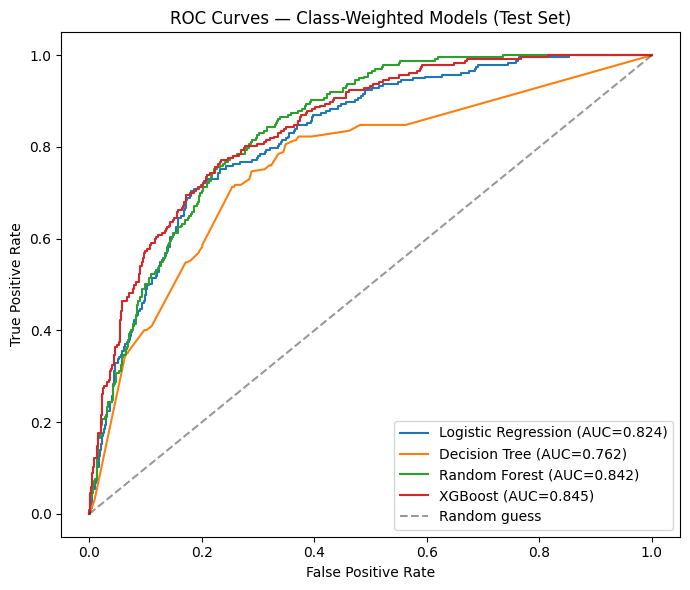

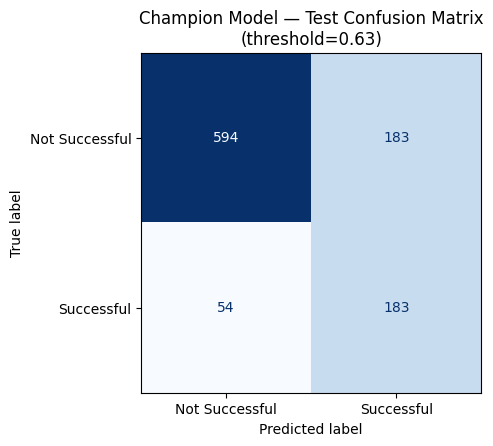

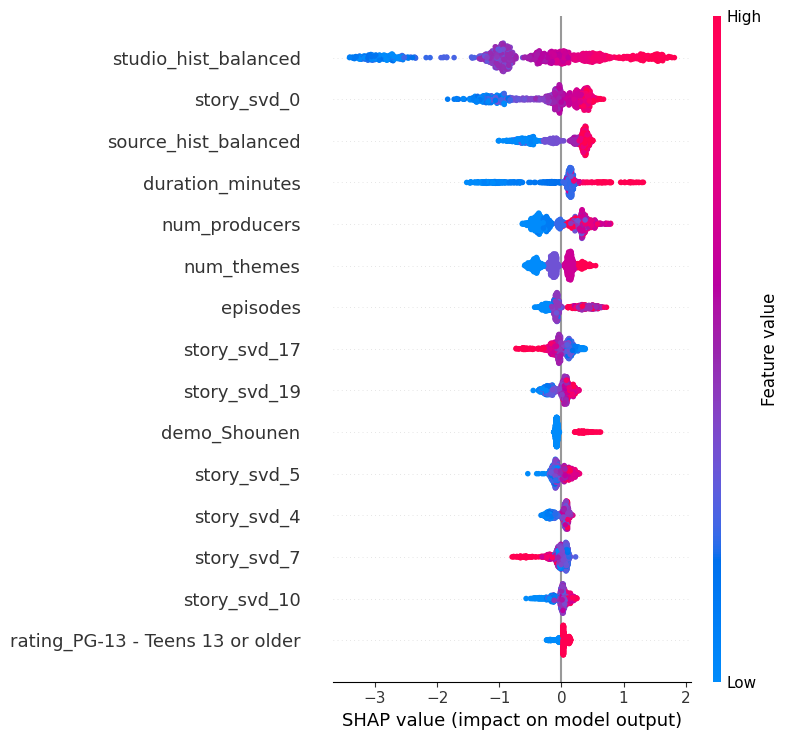

In [11]:
# ============================================================
# Anime Success Classifier — Imbalance Handling, Time-Series CV,
# Model Selection, and SHAP Explanation
#
# Drop these cells into your existing model-training.ipynb, right
# after the FeatureBuilder cell. It reuses the same preprocessing
# logic you already have (parse_list_col, time_split, FeatureBuilder)
# so the feature matrix is identical to your baseline run.
# ============================================================

import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Assumes X_train, X_val, X_test, y_train_cls, y_val_cls, y_test_cls,
# train_df, val_df, test_df, dm and FeatureBuilder already exist from
# your earlier cells. If running standalone, re-run cells 0-8 first.
# ------------------------------------------------------------

y_train, y_val, y_test = y_train_cls, y_val_cls, y_test_cls

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xv_s  = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 4))

# ============================================================
# 1. THREE IMBALANCE-HANDLING STRATEGIES
# ============================================================

# ---- SMOTE oversampling, fit on TRAIN ONLY ----
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
Xtr_s_sm, y_train_sm_s = sm.fit_resample(Xtr_s, y_train)
print("After SMOTE:", X_train_sm.shape, "balance:\n", y_train_sm.value_counts(normalize=True).round(4))

def make_models(weighted, scale_pos_weight=1.0):
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=2000, class_weight='balanced' if weighted else None, random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=5,
            class_weight='balanced' if weighted else None, random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            n_estimators=400, max_depth=10, min_samples_leaf=5,
            class_weight='balanced' if weighted else None, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05, min_child_weight=3,
            subsample=0.7, colsample_bytree=0.7, gamma=0.3,
            scale_pos_weight=(scale_pos_weight if weighted else 1.0),
            eval_metric='logloss', random_state=RANDOM_STATE)
    }

def evaluate(model, Xte, y_true, name, threshold=0.5):
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {'model': name, 'accuracy': accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'f1': f1_score(y_true, pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, proba)}

# Strategy A: class_weight='balanced' / scale_pos_weight, no resampling
models_w = make_models(weighted=True, scale_pos_weight=scale_pos_weight)
resA, fitted_w = [], {}
for name, m in models_w.items():
    if name == 'Logistic Regression':
        m.fit(Xtr_s, y_train); r = evaluate(m, Xte_s, y_test, name)
    else:
        m.fit(X_train, y_train); r = evaluate(m, X_test, y_test, name)
    fitted_w[name] = m; resA.append(r)
dfA = pd.DataFrame(resA).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print("\n=== STRATEGY A: class-weighting (TEST) ===\n", dfA.round(4).to_string(index=False))

# Strategy B: SMOTE oversampling only
models_sm = make_models(weighted=False)
resB, fitted_sm = [], {}
for name, m in models_sm.items():
    if name == 'Logistic Regression':
        m.fit(Xtr_s_sm, y_train_sm_s); r = evaluate(m, Xte_s, y_test, name)
    else:
        m.fit(X_train_sm, y_train_sm); r = evaluate(m, X_test, y_test, name)
    fitted_sm[name] = m; resB.append(r)
dfB = pd.DataFrame(resB).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print("\n=== STRATEGY B: SMOTE oversampling (TEST) ===\n", dfB.round(4).to_string(index=False))

# Strategy C: SMOTE + class-weighting combined (sanity check)
models_smw = make_models(weighted=True, scale_pos_weight=1.0)
resC = []
for name, m in models_smw.items():
    if name == 'Logistic Regression':
        m.fit(Xtr_s_sm, y_train_sm_s); r = evaluate(m, Xte_s, y_test, name)
    else:
        m.fit(X_train_sm, y_train_sm); r = evaluate(m, X_test, y_test, name)
    resC.append(r)
dfC = pd.DataFrame(resC).sort_values('roc_auc', ascending=False).reset_index(drop=True)
print("\n=== STRATEGY C: SMOTE + class-weighting combined (TEST) ===\n", dfC.round(4).to_string(index=False))

# ============================================================
# 2. TIME-SERIES CROSS-VALIDATION (expanding window), ALL 4 MODELS
#    class-weighted, since Strategy A won above
# ============================================================

def build_target(frame, threshold):
    frame = frame.copy()
    frame['is_success_b'] = (frame['balanced_score'] >= threshold).astype(int)
    return frame

cv_folds = [(2018, 2019), (2019, 2020), (2020, 2021), (2021, 2022)]
all_fold_rows = []

for train_end, val_year in cv_folds:
    fold_train = dm[dm['year'] <= train_end].copy()
    fold_val   = dm[dm['year'] == val_year].copy()

    fold_threshold = fold_train['balanced_score'].quantile(0.75)  # re-derived per fold, train-only
    fold_train = build_target(fold_train, fold_threshold)
    fold_val   = build_target(fold_val, fold_threshold)

    fb_fold = FeatureBuilder().fit(fold_train)
    X_tr, X_vl = fb_fold.transform(fold_train), fb_fold.transform(fold_val)
    y_tr, y_vl = fold_train['is_success_b'], fold_val['is_success_b']

    fold_scaler = StandardScaler()
    Xtr_s_f = fold_scaler.fit_transform(X_tr)
    Xvl_s_f = fold_scaler.transform(X_vl)

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    fold_models = make_models(weighted=True, scale_pos_weight=spw)

    for name, model in fold_models.items():
        if name == 'Logistic Regression':
            model.fit(Xtr_s_f, y_tr); proba = model.predict_proba(Xvl_s_f)[:, 1]
        else:
            model.fit(X_tr, y_tr); proba = model.predict_proba(X_vl)[:, 1]
        pred = (proba >= 0.5).astype(int)
        all_fold_rows.append({'model': name, 'train_years': f'2010-{train_end}', 'val_year': val_year,
                               'n_train': len(fold_train), 'n_val': len(fold_val),
                               'accuracy': accuracy_score(y_vl, pred),
                               'precision': precision_score(y_vl, pred, zero_division=0),
                               'recall': recall_score(y_vl, pred, zero_division=0),
                               'f1': f1_score(y_vl, pred, zero_division=0),
                               'roc_auc': roc_auc_score(y_vl, proba)})

cv_df = pd.DataFrame(all_fold_rows)
print("\n=== Per-fold time-series CV results ===")
print(cv_df.round(4).to_string(index=False))

cv_summary = cv_df.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].agg(['mean', 'std']).round(4)
print("\n=== Mean +/- Std across folds ===")
print(cv_summary)

# ============================================================
# 3. FINAL MODEL: validation-based threshold search + TEST evaluation
# ============================================================

champion = fitted_w['XGBoost']  # replace with whichever model wins your CV ranking

proba_val = champion.predict_proba(X_val)[:, 1]
thr_rows = []
for t in np.arange(0.30, 0.81, 0.01):
    pred = (proba_val >= t).astype(int)
    thr_rows.append({'threshold': t, 'accuracy': accuracy_score(y_val, pred),
                      'precision': precision_score(y_val, pred, zero_division=0),
                      'recall': recall_score(y_val, pred, zero_division=0),
                      'f1': f1_score(y_val, pred, zero_division=0)})
thr_df = pd.DataFrame(thr_rows)
best_row = thr_df.loc[thr_df['f1'].idxmax()]
best_threshold = best_row['threshold']
print("\n=== Best threshold on validation (max F1) ===\n", best_row.round(4))

proba_test = champion.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= best_threshold).astype(int)

print("\n=== FINAL MODEL — TEST RESULTS ===")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, pred_test):.4f}")
print(f"Precision : {precision_score(y_test, pred_test, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, pred_test, zero_division=0):.4f}")
print(f"F1        : {f1_score(y_test, pred_test, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba_test):.4f}")
print("\n", classification_report(y_test, pred_test, digits=4, zero_division=0))

cm = confusion_matrix(y_test, pred_test)
print("Confusion matrix:\n", cm)

# ROC curves, all 4 weighted models
plt.figure(figsize=(7, 6))
for name, model in fitted_w.items():
    Xte = Xte_s if name == 'Logistic Regression' else X_test
    p = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, p):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Class-Weighted Models (Test Set)')
plt.legend(); plt.tight_layout(); plt.savefig('roc_curves_test.png', dpi=150, bbox_inches='tight')

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Successful', 'Successful']).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Champion Model — Test Confusion Matrix\n(threshold={best_threshold:.2f})')
plt.tight_layout(); plt.savefig('confusion_matrix_champion.png', dpi=150, bbox_inches='tight')

# ============================================================
# 4. SHAP EXPLANATION OF THE CHAMPION MODEL
# ============================================================
import shap

explainer = shap.TreeExplainer(champion)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout(); plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
print("\n=== Top 15 features by mean |SHAP value| ===")
print(mean_abs_shap.head(15).round(4))